In [1]:
!pip -q install --upgrade diffusers==0.36.0 transformers accelerate peft bitsandbytes clean-fid xformers opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 80.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 71.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 23.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 4.3 MB/s eta 0:00:000:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 106.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 20.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import glob
import gc
import json
import cv2
import random
import shutil
import subprocess
import numpy as np
import pandas as pd
import torch

from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from IPython.display import display

PROJECT_ROOT = "/kaggle/working/RELEIF_STABLEDIFFUSION"

DATA_ROOT = os.path.join(PROJECT_ROOT, "data")
INSTANCE_ROOT = os.path.join(DATA_ROOT, "instance_data")
MODEL_ROOT = os.path.join(PROJECT_ROOT, "models")
GEN_ROOT = os.path.join(PROJECT_ROOT, "generated")
SCRIPT_ROOT = os.path.join(PROJECT_ROOT, "scripts")

for p in [PROJECT_ROOT, DATA_ROOT, INSTANCE_ROOT, MODEL_ROOT, GEN_ROOT, SCRIPT_ROOT]:
    os.makedirs(p, exist_ok=True)

print(PROJECT_ROOT)

/kaggle/working/RELEIF_STABLEDIFFUSION


In [8]:
RAW_DATA_ROOT = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

PART1 = os.path.join(RAW_DATA_ROOT, "HAM10000_images_part_1")
PART2 = os.path.join(RAW_DATA_ROOT, "HAM10000_images_part_2")
METADATA_CSV = os.path.join(RAW_DATA_ROOT, "HAM10000_metadata.csv")

print("PART1 exists:", os.path.exists(PART1))
print("PART2 exists:", os.path.exists(PART2))
print("CSV exists:", os.path.exists(METADATA_CSV))

PART1 exists: True
PART2 exists: True
CSV exists: True



#### The command is used to download a pre-built training script from Hugging Face Diffusers, which implements DreamBooth with LoRA for fine-tuning diffusion models. It saves development time, ensures compatibility, and provides a reliable pipeline for training without writing complex code from scratch. Mainly used because this script already does the following :
- Dataset loading
- Model setup
- Loss functions
- Optimizer
- GPU handling

 

Hugging Face, 2023. train_dreambooth_lora.py. Available at: https://github.com/huggingface/diffusers/blob/v0.36.0/examples/dreambooth/train_dreambooth_lora.py
 (Accessed: 03 january 2026).

In [ ]:
HF_TRAIN_SCRIPT = os.path.join(SCRIPT_ROOT, "train_dreambooth_lora.py")

!wget -q -O "{HF_TRAIN_SCRIPT}" https://raw.githubusercontent.com/huggingface/diffusers/v0.36.0/examples/dreambooth/train_dreambooth_lora.py

print("Script path:", HF_TRAIN_SCRIPT)
print("Exists:", os.path.exists(HF_TRAIN_SCRIPT))
!ls -lh "{SCRIPT_ROOT}"

Script path: /kaggle/working/RELEIF_STABLEDIFFUSION/scripts/train_dreambooth_lora.py
Exists: True
total 60K
-rw-r--r-- 1 root root 58K Mar 10 07:51 train_dreambooth_lora.py


In [ ]:
BASE_MODEL = "runwayml/stable-diffusion-v1-5"
CONTROLNET_MODEL = "lllyasviel/sd-controlnet-canny"

IMG_SIZE = 512
TRAIN_RESOLUTION = 512
TRAIN_BATCH_SIZE = 1
GRAD_ACCUM = 1
LORA_LR = 2e-4
CHECKPOINTING_STEPS = 100
SEED = 42

NUM_INFERENCE_STEPS = 40
GUIDANCE_SCALE = 6.5
LOW_THRESHOLD = 100
HIGH_THRESHOLD = 200
CONTROLNET_CONDITIONING_SCALE = 1.0
CONTROL_GUIDANCE_START = 0.0
CONTROL_GUIDANCE_END = 1.0

NEGATIVE_PROMPT = (
    "cartoon, illustration, low quality, blurry, distorted, deformed, noisy, "
    "watermark, text, unrealistic skin, duplicate lesion"
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

CLASS_CONFIGS = {
    "mel": {
        "code": "MEL",
        "prompt": "melanoma dermoscopic image, clinical dermatology, dermoscopy, high detail, realistic skin lesion",
        "train_steps": 400,
    },
    "nv": {
        "code": "NV",
        "prompt": "melanocytic nevus dermoscopic image, clinical dermatology, dermoscopy, high detail, realistic skin lesion",
        "train_steps": 400,
    },
    "bcc": {
        "code": "BCC",
        "prompt": "basal cell carcinoma dermoscopic image, clinical dermatology, dermoscopy, high detail, realistic skin lesion",
        "train_steps": 400,
    },
    "bkl": {
        "code": "BKL",
        "prompt": "benign keratosis dermoscopic image, clinical dermatology, dermoscopy, high detail, realistic skin lesion",
        "train_steps": 400,
    },
    "akiec": {
        "code": "AKIEC",
        "prompt": "actinic keratosis dermoscopic image, clinical dermatology, dermoscopy, high detail, realistic skin lesion",
        "train_steps": 300,
    },
    "vasc": {
        "code": "VASC",
        "prompt": "vascular lesion dermoscopic image, clinical dermatology, dermoscopy, high detail, realistic skin lesion",
        "train_steps": 200,
    },
    "df": {
        "code": "DF",
        "prompt": "dermatofibroma dermoscopic image, clinical dermatology, dermoscopy, high detail, realistic skin lesion",
        "train_steps": 200,
    },
}

print("Device:", DEVICE)

Device: cuda


In [ ]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

metadata_df = pd.read_csv(METADATA_CSV)

def build_image_path_map():
    all_paths = sorted(
        glob.glob(os.path.join(PART1, "*.jpg")) +
        glob.glob(os.path.join(PART2, "*.jpg"))
    )
    return {Path(p).stem: p for p in all_paths}

path_map = build_image_path_map()

def get_class_real_paths(dx_label):
    sub = metadata_df[metadata_df["dx"] == dx_label].copy()
    image_ids = sub["image_id"].tolist()
    return [path_map[i] for i in image_ids if i in path_map]

print(metadata_df["dx"].value_counts())
print("Mapped images:", len(path_map))

dx
nv       4693
mel      779
bkl      769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64
Mapped images: 7010


In [ ]:
def prepare_class_instance_data(dx_label):
    class_dir = os.path.join(INSTANCE_ROOT, dx_label)
    os.makedirs(class_dir, exist_ok=True)

    real_paths = get_class_real_paths(dx_label)
    copied = 0

    for src in tqdm(real_paths, desc=f"Copying {dx_label}"):
        dst = os.path.join(class_dir, os.path.basename(src))
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        copied += 1

    print(f"{dx_label}: {copied} images copied to {class_dir}")
    return class_dir

In [ ]:
def dullrazor_hair_remove(img_bgr, kernel_size=17, inpaint_radius=1):
 	"""Detects and removes hair artifacts from image"""
    # Convert image to grayscale for morphological filtering
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Use BlackHat morphological operation to highlight dark hair against light skin
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    # Binarize the highlighted hairs and dilate them slightly to ensure complete coverage
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(hair_mask, np.ones((3, 3), np.uint8), iterations=1)

    # Inpaint the original RGB image to smoothly replace the segmented hair pixels
    cleaned = cv2.inpaint(img_bgr, hair_mask, inpaint_radius, cv2.INPAINT_TELEA)
    return cleaned, hair_mask

def fallback_lesion_mask(size=512):
    # Initialize a blank square image mask
    mask = np.zeros((size, size), dtype=np.uint8)
    
    # Calculate regular geometric center and focal ellipse sizes correlating to general lesion size
    center = (size // 2, size // 2)
    axes = (int(size * 0.22), int(size * 0.18))
    
    # Draw the solid ellipse onto the empty mask and lightly dilate
    cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)
    mask = cv2.dilate(mask, np.ones((7, 7), np.uint8), iterations=1)
    return mask

def lesion_guided_canny(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Resize raw image dynamically to match Stable Diffusion dimensions
    img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    
    # Preprocess image to strip hair artifacts structurally seamlessly using DullRazor
    img_bgr, hair_mask = dullrazor_hair_remove(img_bgr)

    # Convert mapped image directly into Grayscale and blur to suppress high-frequency noise
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Generate the elliptic bounding mask
    lesion_mask = fallback_lesion_mask(IMG_SIZE)

    # Extract overall Canny edges limited algorithmically via global threshold constants
    edges = cv2.Canny(gray, LOW_THRESHOLD, HIGH_THRESHOLD)
    
    # Perform bitwise intersection combining all extracted edges with the focal mask strictly
    lesion_edges = cv2.bitwise_and(edges, edges, mask=lesion_mask)

    # Restore mapped structural image completely optimized for Diffusers
    control_img = Image.fromarray(lesion_edges).convert("RGB")
    return control_img, hair_mask, lesion_mask

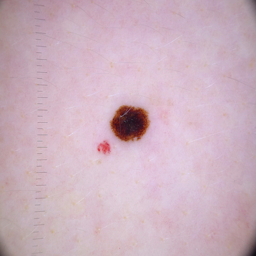

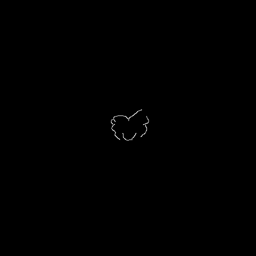

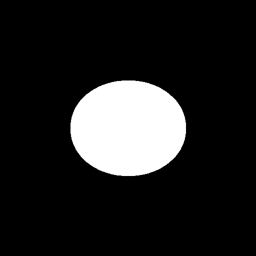

In [ ]:
mel_paths = get_class_real_paths("mel")
sample_img = mel_paths[0]

control_img, hair_mask, lesion_mask = lesion_guided_canny(sample_img)

display(Image.open(sample_img).resize((256, 256)))
display(control_img.resize((256, 256)))
display(Image.fromarray(lesion_mask).resize((256, 256)))

In [ ]:
def train_class(dx_label):
    if not os.path.exists(HF_TRAIN_SCRIPT):
        raise FileNotFoundError(f"Training script not found: {HF_TRAIN_SCRIPT}")

    cfg = CLASS_CONFIGS[dx_label]
    prompt = cfg["prompt"]
    train_steps = cfg["train_steps"]

    instance_dir = prepare_class_instance_data(dx_label)
    out_dir = os.path.join(MODEL_ROOT, f"sd15_ham_{dx_label}_lora_lr_2e04")
    os.makedirs(out_dir, exist_ok=True)

    cmd = [
        "accelerate", "launch",
        "--num_processes=1",
        "--mixed_precision=bf16",
        HF_TRAIN_SCRIPT,
        f"--pretrained_model_name_or_path={BASE_MODEL}",
        f"--instance_data_dir={instance_dir}",
        f"--output_dir={out_dir}",
        f"--instance_prompt={prompt}",
        f"--resolution={TRAIN_RESOLUTION}",
        "--center_crop",
        f"--train_batch_size={TRAIN_BATCH_SIZE}",
        f"--gradient_accumulation_steps={GRAD_ACCUM}",
        f"--learning_rate={LORA_LR}",
        "--lr_scheduler=constant",
        "--lr_warmup_steps=0",
        f"--max_train_steps={train_steps}",
        f"--checkpointing_steps={CHECKPOINTING_STEPS}",
        "--gradient_checkpointing",
    ]

    print("\nTraining class:", dx_label)
    print("Saving to:", out_dir)
    print("Command:\n", " ".join([f'"{c}"' if " " in c else c for c in cmd]))

    subprocess.run(cmd, check=True)

    print(f"Training complete for {dx_label}")
    return out_dir

In [ ]:
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline, UniPCMultistepScheduler

def load_generation_pipeline(lora_dir):
    """
    Initializes and configures the Stable Diffusion pipeline integrated with ControlNet and LoRA.
    
    Args:
        lora_dir (str): Path to the directory containing the fine-tuned LoRA weights.
        
    Returns:
        StableDiffusionControlNetPipeline: The fully configured image generation pipeline.
    """
    
    # 1. Load the ControlNet model (e.g., Canny edge detector) to guide the generation shape
    # This enforces structural constraints on the generated synthetic lesion.
    controlnet = ControlNetModel.from_pretrained(
        CONTROLNET_MODEL,
        torch_dtype=TORCH_DTYPE
    )

    # 2. Initialize the base Stable Diffusion pipeline with the ControlNet attached
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        BASE_MODEL,
        controlnet=controlnet,
        torch_dtype=TORCH_DTYPE,
        # Safety checker explicitly disabled to prevent false positive NSFW flags on medical/skin images
        safety_checker=None,          
        requires_safety_checker=False 
    ).to(DEVICE) # Move the pipeline to the target device (e.g., 'cuda' for GPU)

    # 3. Swap the default scheduler for UniPCMultistepScheduler
    # A highly efficient formulation requiring fewer inference steps, accelerating generation
    pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
    
    # 4. Inject the custom LoRA weights fine-tuned on the skin lesion dataset (Melanoma/BCC)
    pipe.load_lora_weights(lora_dir)

    # 5. Enable attention slicing to significantly reduce VRAM footprint
    # Ensures batch generation scales gracefully on consumer-level GPUs without Out-Of-Memory errors
    if hasattr(pipe, "enable_attention_slicing"):
        pipe.enable_attention_slicing()

    return pipe


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
def generate_for_class(dx_label, num_images=300):
    cfg = CLASS_CONFIGS[dx_label]
    class_code = cfg["code"]
    prompt = cfg["prompt"]

    lora_dir = os.path.join(MODEL_ROOT, f"sd15_ham_{dx_label}_lora_lr_2e04")
    if not os.path.exists(lora_dir):
        raise FileNotFoundError(f"LoRA model not found: {lora_dir}")

    out_dir = os.path.join(GEN_ROOT, class_code)
    os.makedirs(out_dir, exist_ok=True)

    preview_dir = os.path.join(out_dir, "_previews")
    os.makedirs(preview_dir, exist_ok=True)

    real_paths = get_class_real_paths(dx_label)
    sampled_real_paths = random.choices(real_paths, k=num_images)

    existing = len(glob.glob(os.path.join(out_dir, "*.png")))

    print(f"\nGenerating for {dx_label}")
    print("Using model:", lora_dir)
    print("Saving images to:", out_dir)
    print("Starting from index:", existing + 1)

    pipe = load_generation_pipeline(lora_dir)

    generated_files = []

    for idx, real_img_path in enumerate(tqdm(sampled_real_paths, desc=f"Generating {dx_label}")):
        control_img, hair_mask, lesion_mask = lesion_guided_canny(real_img_path)

        generator = torch.Generator(device=DEVICE).manual_seed(SEED + existing + idx)

        result = pipe(
            prompt=prompt,
            negative_prompt=NEGATIVE_PROMPT,
            image=control_img,
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            controlnet_conditioning_scale=CONTROLNET_CONDITIONING_SCALE,
            control_guidance_start=CONTROL_GUIDANCE_START,
            control_guidance_end=CONTROL_GUIDANCE_END,
            generator=generator,
        )

        out_name = f"syn_{class_code}_{existing + idx + 1:04d}.png"
        out_path = os.path.join(out_dir, out_name)
        result.images[0].save(out_path)
        generated_files.append(out_path)

        if idx < 5:
            control_img.save(os.path.join(preview_dir, f"control_{idx+1:02d}.png"))
            Image.fromarray(hair_mask).save(os.path.join(preview_dir, f"hairmask_{idx+1:02d}.png"))
            Image.fromarray(lesion_mask).save(os.path.join(preview_dir, f"lesionmask_{idx+1:02d}.png"))

    manifest = {
        "class": dx_label,
        "class_code": class_code,
        "num_generated": len(generated_files),
        "prompt": prompt,
        "guidance_scale": GUIDANCE_SCALE,
        "low_threshold": LOW_THRESHOLD,
        "high_threshold": HIGH_THRESHOLD,
        "controlnet_conditioning_scale": CONTROLNET_CONDITIONING_SCALE,
    }

    with open(os.path.join(out_dir, "run_manifest.json"), "w") as f:
        json.dump(manifest, f, indent=2)

    del pipe
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"Done generating {len(generated_files)} images for {dx_label}")
    return out_dir

In [ ]:
def run_class(dx_label, num_images=300, retrain=False):
    lora_dir = os.path.join(MODEL_ROOT, f"sd15_ham_{dx_label}_lora_lr_2e04")

    if retrain or not os.path.exists(lora_dir):
        train_class(dx_label)
    else:
        print(f"Using existing trained model for {dx_label}: {lora_dir}")

    return generate_for_class(dx_label, num_images=num_images)

def run_mel(num_images=300, retrain=False):
    return run_class("mel", num_images=num_images, retrain=retrain)

def run_nv(num_images=300, retrain=False):
    return run_class("nv", num_images=num_images, retrain=retrain)

def run_bcc(num_images=300, retrain=False):
    return run_class("bcc", num_images=num_images, retrain=retrain)

def run_bkl(num_images=300, retrain=False):
    return run_class("bkl", num_images=num_images, retrain=retrain)

def run_akiec(num_images=300, retrain=False):
    return run_class("akiec", num_images=num_images, retrain=retrain)

def run_vasc(num_images=300, retrain=False):
    return run_class("vasc", num_images=num_images, retrain=retrain)

def run_df(num_images=300, retrain=False):
    return run_class("df", num_images=num_images, retrain=retrain)

print("Per-class wrappers ready.")

Per-class wrappers ready.


In [ ]:
train_class("mel")

Copying mel:   0%|          | 0/779 [00:00<?, ?it/s]

mel: 779 images copied to /kaggle/working/RELEIF_STABLEDIFFUSION/data/instance_data/mel

Training class: mel
Saving to: /kaggle/working/RELEIF_STABLEDIFFUSION/models/sd15_ham_mel_lora_lr_2e04
Command:
 accelerate launch --num_processes=1 --mixed_precision=bf16 /kaggle/working/RELEIF_STABLEDIFFUSION/scripts/train_dreambooth_lora.py --pretrained_model_name_or_path=runwayml/stable-diffusion-v1-5 --instance_data_dir=/kaggle/working/RELEIF_STABLEDIFFUSION/data/instance_data/mel --output_dir=/kaggle/working/RELEIF_STABLEDIFFUSION/models/sd15_ham_mel_lora_lr_2e04 "--instance_prompt=melanoma dermoscopic image, clinical dermatology, dermoscopy, high detail, realistic skin lesion" --resolution=512 --center_crop --train_batch_size=1 --gradient_accumulation_steps=1 --learning_rate=0.0002 --lr_scheduler=constant --lr_warmup_steps=0 --max_train_steps=400 --checkpointing_steps=100 --gradient_checkpointing


The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
You are using a model of type `clip_text_model` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
/usr/local/lib/python3.12/dist-package

Training complete for mel


'/kaggle/working/RELEIF_STABLEDIFFUSION/models/sd15_ham_mel_lora_lr_2e04'

In [ ]:
generate_for_class("mel", num_images=1000)


Generating for mel
Using model: /kaggle/working/RELEIF_STABLEDIFFUSION/models/sd15_ham_mel_lora_lr_2e04
Saving images to: /kaggle/working/RELEIF_STABLEDIFFUSION/generated/MEL
Starting from index: 1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
train_class("bcc")